In [3]:
#import libraries
!pip install shap
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [4]:
#load dataset
df = pd.read_csv('data/Processed Data/processed_data.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [6]:
#train best model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

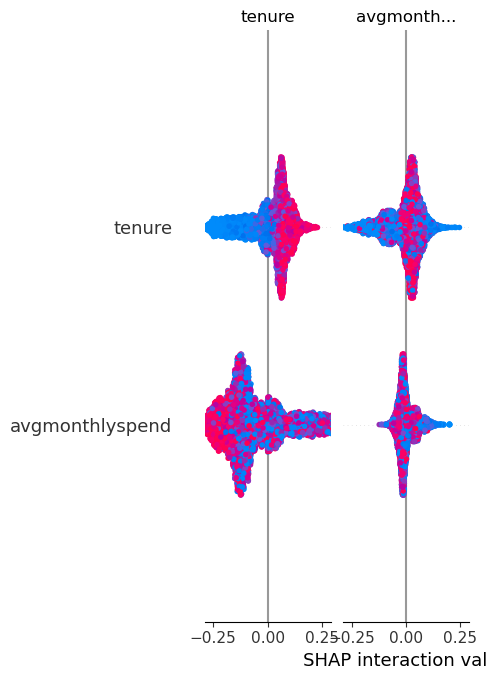

In [8]:
#global feature importance
shap.summary_plot(shap_values, X)

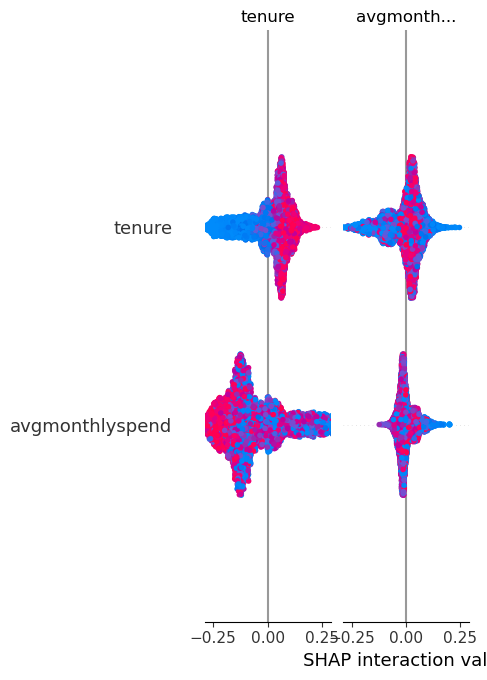

In [9]:
#Bar plot
shap.summary_plot(shap_values, X, plot_type="bar")

In [10]:
#Local explanation for 2 customers
#pick 1 customer who churned and 1 who did not
churned = X[y == 1].iloc[0]
not_churned = X[y == 0].iloc[0]

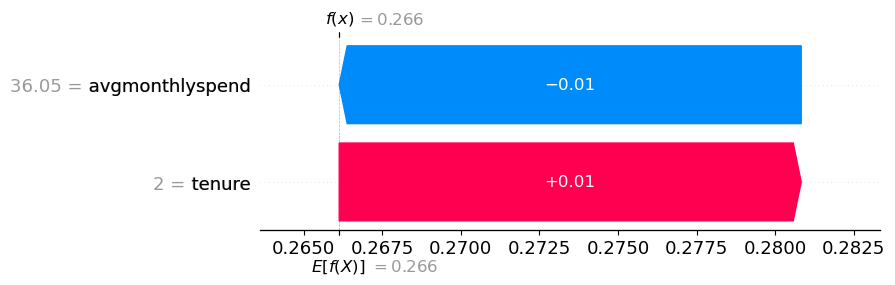

In [11]:
#Explain prediction
#churned customer
idx = X[y == 1].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][idx],
        base_values=explainer.expected_value[1],
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

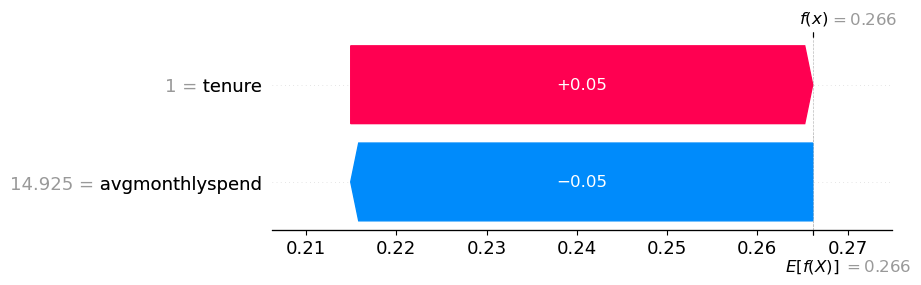

In [12]:
#not churned customer
idx = X[y == 0].index[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][idx],
        base_values=explainer.expected_value[1],
        data=X.iloc[idx],
        feature_names=X.columns
    )
)

c:\Users\VIDYA\Downloads\anaconda\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


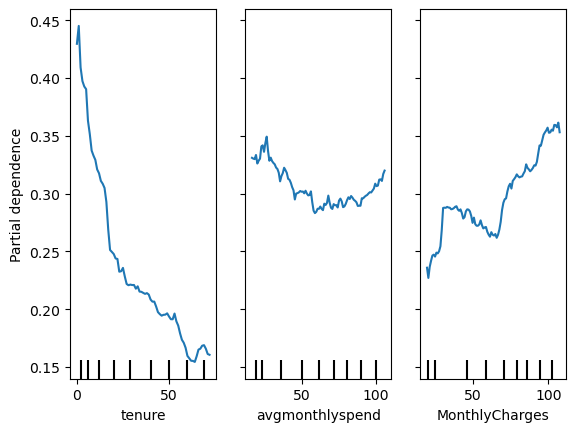

In [13]:
#partial dependence plot for top feature
from sklearn.inspection import PartialDependenceDisplay

features = X.columns[:3]  # top 3 features

PartialDependenceDisplay.from_estimator(model, X, features)
plt.show()

Top 5 factors driving churn
- Contract type (Month-to-month customers churn more)
- Tenure (new customers churn more)
- MonthlyCharges (higher charges → higher churn)
- InternetService (Fiber optic users churn more)
- Lack of TechSupport / OnlineSecurity

High-risk customer segments 
- Customers with short tenure
- Month-to-month contract users
- High monthly charges
- Customers without support services

Pricing strategy recommendation
- Offer discounts for long-term contracts
- Provide bundled services
- Reduce cost for high-paying customers

In [14]:
#Which 100 customers to target
probs = model.predict_proba(X)[:,1]

top_customers = pd.DataFrame({
    'risk': probs
}).sort_values(by='risk', ascending=False).head(100)

top_customers

,risk
3030,1.00
2084,1.00
1731,1.00
207,1.00
4848,1.00
...,...
6748,0.98
1073,0.98
2631,0.98
6633,0.98


Select customers with highest churn probability

In [15]:
#ROI analysis
retention_cost = 50
loss = 500

saved_customers = 100
total_cost = saved_customers * retention_cost
total_savings = saved_customers * loss

roi = (total_savings - total_cost) / total_cost

print("ROI:", roi)

ROI: 9.0


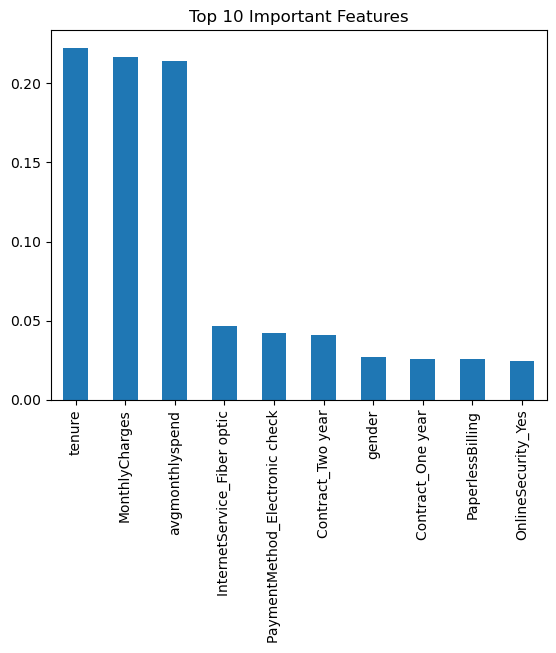

In [16]:
#Feature imoportance plot
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

“Model interpretation was performed using SHAP values to understand feature contributions. Global and local explanations revealed key drivers of churn. Business recommendations were derived based on model insights to improve customer retention and optimize revenue.”